**Описание задачи**  
Добро пожаловать в 2912 год, где ваши навыки работы с данными потребуются для решения космической загадки. Мы получили сообщение с расстояния в четыре световых года, и дела обстоят не лучшим образом.

Космический корабль «Астра» — межзвездный пассажирский лайнер, запущенный месяц назад.

С почти 13 000 пассажиров на борту судно отправилось в свой первый рейс, перевозя эмигрантов из нашей Солнечной системы на три новые пригодные для жизни экзопланеты, вращающиеся вокруг ближайших звезд.
Огибая систему Альфа Центавра по пути к первому пункту назначения — знойной планете 55 Cancri E, — космический корабль «Астра» столкнулся с пространственно-временной аномалией, скрытой в пылевом облаке. Хотя корабль остался цел, почти половина пассажиров была перенесена в альтернативное измерение!

Чтобы помочь спасателям и вернуть потерянных пассажиров, вам предстоит предсказать, кого из них перенесла аномалия, используя записи, извлеченные из поврежденной компьютерной системы корабля.

Помогите спасти их и изменить историю!

**Задание**

Ваша задача — предсказать, был ли пассажир перенесен в альтернативное измерение во время столкновения космического корабля «Астра» с пространственно-временной аномалией. Для этого вам предоставлен набор личных записей, извлеченных из поврежденной компьютерной системы корабля.

Вам необходимо:

реализовать алгоритм классификации, который сможет по имеющимся данным определить, перенесен пассажир или нет;
получить предсказания на тестовых данных (файл public_test.csv);
загрузить .csv файл с предсказаниями.

In [33]:

import pandas as pd


In [77]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("public_test.csv") 

In [35]:
# Проверка загрузки данных
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain columns:", train_df.columns.tolist())
print("\nTest columns:", test_df.columns.tolist())

Train shape: (8693, 14)
Test shape: (2138, 13)

Train columns: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']

Test columns: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name']


In [36]:
print(train_df.head().to_markdown())

|    |   PassengerId | HomePlanet   | CryoSleep   | Cabin   | Destination   |   Age | VIP   |   RoomService |   FoodCourt |   ShoppingMall |   Spa |   VRDeck | Name              | Transported   |
|---:|--------------:|:-------------|:------------|:--------|:--------------|------:|:------|--------------:|------------:|---------------:|------:|---------:|:------------------|:--------------|
|  0 |       0001_01 | Europa       | False       | B/0/P   | TRAPPIST-1e   |    39 | False |             0 |           0 |              0 |     0 |        0 | Maham Ofracculy   | False         |
|  1 |       0002_01 | Earth        | False       | F/0/S   | TRAPPIST-1e   |    24 | False |           109 |           9 |             25 |   549 |       44 | Juanna Vines      | True          |
|  2 |       0003_01 | Europa       | False       | A/0/S   | TRAPPIST-1e   |    58 | True  |            43 |        3576 |              0 |  6715 |       49 | Altark Susent     | False         |
|  3 |       0003_02

In [37]:
import pandas as pd

# Выводим распределение целевой переменной
print("Распределение Transported:")
print(train_df['Transported'].value_counts())
print("\nВ процентном соотношении:")
print(train_df['Transported'].value_counts(normalize=True) * 100)


Распределение Transported:
Transported
True     4378
False    4315
Name: count, dtype: int64

В процентном соотношении:
Transported
True     50.362361
False    49.637639
Name: proportion, dtype: float64


In [38]:
# Проверка на пропуски
print("Пропуски в train:")
print(train_df.isnull().sum())
print("\nПропуски в test:")
print(test_df.isnull().sum())


Пропуски в train:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

Пропуски в test:
PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
dtype: int64


In [39]:
# Заполним пропуски в числовых столбцах средним значением
# Определим числовые столбцы (примерно, исходя из описания)
numeric_columns = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in numeric_columns:
    if col in train_df.columns:
        mean_val = train_df[col].mean()
        train_df[col] = train_df[col].fillna(mean_val)
        if col in test_df.columns: # Проверяем, существует ли столбец в тесте
            test_df[col] = test_df[col].fillna(mean_val)

In [40]:
# Заполним пропуски в категориальных и бинарных столбцах наиболее частым значением (mode)
categorical_and_binary_columns = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
for col in categorical_and_binary_columns:
    if col in train_df.columns:
        mode_val = train_df[col].mode()[0] if not train_df[col].mode().empty else 'Unknown' # Обработка случая без моды
        train_df[col] = train_df[col].fillna(mode_val)
        if col in test_df.columns: # Проверяем, существует ли столбец в тесте
            test_df[col] = test_df[col].fillna(mode_val)

/tmp/ipykernel_24553/2379943577.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df[col] = train_df[col].fillna(mode_val)


In [41]:
# Для столбцов Cabin и Name можно заполнить пропуски строкой 'Unknown'
if 'Cabin' in train_df.columns:
    train_df['Cabin'] = train_df['Cabin'].fillna('Unknown')
    test_df['Cabin'] = test_df['Cabin'].fillna('Unknown')

if 'Name' in train_df.columns:
    train_df['Name'] = train_df['Name'].fillna('Unknown')
    test_df['Name'] = test_df['Name'].fillna('Unknown')


In [42]:
import pandas as pd
import numpy as np

def extract_features(df):
    df = df.copy()

    # --- PassengerId: group & position
    df[['Group', 'GroupPos']] = df['PassengerId'].str.split('_', expand=True)
    group_counts = df['Group'].value_counts()
    df['GroupSize'] = df['Group'].map(group_counts)
    df['IsAlone'] = (df['GroupSize'] == 1)

    # --- Cabin: deck / num / side
    cabin_split = df['Cabin'].str.split('/', expand=True)
    df['Cabin_deck'] = cabin_split[0]
    df['Cabin_num'] = pd.to_numeric(cabin_split[1], errors='coerce')
    df['Cabin_side'] = cabin_split[2]

    # --- Name: last name & family size
    df['LastName'] = df['Name'].str.split().str[-1]
    family_counts = df['LastName'].value_counts()
    df['FamilySize'] = df['LastName'].map(family_counts).fillna(1)

    return df

# Применяем к train и test
train_df_ext = extract_features(train_df)
test_df_ext = extract_features(test_df)

# Проверим, какие колонки добавились
print("Новые колонки в train_df_ext:", [col for col in train_df_ext.columns if col not in train_df.columns])
print("\nПример первых 3 строк новых признаков:")
print(train_df_ext[['Group', 'GroupSize', 'IsAlone', 'Cabin_deck', 'Cabin_num', 'Cabin_side', 'LastName', 'FamilySize']].head(3))

Новые колонки в train_df_ext: ['Group', 'GroupPos', 'GroupSize', 'IsAlone', 'Cabin_deck', 'Cabin_num', 'Cabin_side', 'LastName', 'FamilySize']

Пример первых 3 строк новых признаков:
  Group  GroupSize  IsAlone Cabin_deck  Cabin_num Cabin_side   LastName  \
0  0001          1     True          B        0.0          P  Ofracculy   
1  0002          1     True          F        0.0          S      Vines   
2  0003          2    False          A        0.0          S     Susent   

   FamilySize  
0           1  
1           4  
2           6  


In [45]:
print(train_df_ext.head().to_markdown())

|    |   PassengerId | HomePlanet   | CryoSleep   | Cabin   | Destination   |   Age | VIP   |   RoomService |   FoodCourt |   ShoppingMall |   Spa |   VRDeck | Name              | Transported   |   Group |   GroupPos |   GroupSize | IsAlone   | Cabin_deck   |   Cabin_num | Cabin_side   | LastName    |   FamilySize |
|---:|--------------:|:-------------|:------------|:--------|:--------------|------:|:------|--------------:|------------:|---------------:|------:|---------:|:------------------|:--------------|--------:|-----------:|------------:|:----------|:-------------|------------:|:-------------|:------------|-------------:|
|  0 |       0001_01 | Europa       | False       | B/0/P   | TRAPPIST-1e   |    39 | False |             0 |           0 |              0 |     0 |        0 | Maham Ofracculy   | False         |    0001 |         01 |           1 | True      | B            |           0 | P            | Ofracculy   |            1 |
|  1 |       0002_01 | Earth        | False   

In [46]:
def add_spending_features(df):
    df = df.copy()
    # Общие и категоризированные траты
    df['TotalSpent'] = df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)
    df['LuxurySpent'] = df[['Spa', 'VRDeck', 'RoomService']].sum(axis=1)
    df['EssentialSpent'] = df[['FoodCourt', 'ShoppingMall']].sum(axis=1)
    
    # Бинарные флаги
    df['HasSpent'] = (df['TotalSpent'] > 0).astype(int)
    df['IsCryoSleepTrue'] = df['CryoSleep'].astype(int)  # для удобства в моделях
    
    # Лог-трансформ (избегаем -inf для нулей)
    df['LogTotalSpent'] = np.log1p(df['TotalSpent'])
    df['LogLuxurySpent'] = np.log1p(df['LuxurySpent'])
    
    return df

# Применяем к train_df_ext и test_df_ext
train_df_ext = add_spending_features(train_df_ext)
test_df_ext = add_spending_features(test_df_ext)

# Выводим пример
print("Новые колонки (расходы):", [c for c in train_df_ext.columns if 'Spent' in c or 'Has' in c or 'Log' in c or 'IsCryo' in c])
print("\nПример:")
print(train_df_ext[['TotalSpent', 'LuxurySpent', 'EssentialSpent', 'HasSpent', 'IsCryoSleepTrue', 'LogTotalSpent']].head(3))

Новые колонки (расходы): ['TotalSpent', 'LuxurySpent', 'EssentialSpent', 'HasSpent', 'IsCryoSleepTrue', 'LogTotalSpent', 'LogLuxurySpent']

Пример:
   TotalSpent  LuxurySpent  EssentialSpent  HasSpent  IsCryoSleepTrue  \
0         0.0          0.0             0.0         0                0   
1       736.0        702.0            34.0         1                0   
2     10383.0       6807.0          3576.0         1                0   

   LogTotalSpent  
0       0.000000  
1       6.602588  
2       9.248021  


In [47]:
print(train_df_ext.head().to_markdown())

|    |   PassengerId | HomePlanet   | CryoSleep   | Cabin   | Destination   |   Age | VIP   |   RoomService |   FoodCourt |   ShoppingMall |   Spa |   VRDeck | Name              | Transported   |   Group |   GroupPos |   GroupSize | IsAlone   | Cabin_deck   |   Cabin_num | Cabin_side   | LastName    |   FamilySize |   TotalSpent |   LuxurySpent |   EssentialSpent |   HasSpent |   IsCryoSleepTrue |   LogTotalSpent |   LogLuxurySpent |
|---:|--------------:|:-------------|:------------|:--------|:--------------|------:|:------|--------------:|------------:|---------------:|------:|---------:|:------------------|:--------------|--------:|-----------:|------------:|:----------|:-------------|------------:|:-------------|:------------|-------------:|-------------:|--------------:|-----------------:|-----------:|------------------:|----------------:|-----------------:|
|  0 |       0001_01 | Europa       | False       | B/0/P   | TRAPPIST-1e   |    39 | False |             0 |           0 | 

In [50]:
train_df_ext.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported', 'Group', 'GroupPos', 'GroupSize', 'IsAlone',
       'Cabin_deck', 'Cabin_num', 'Cabin_side', 'LastName', 'FamilySize',
       'TotalSpent', 'LuxurySpent', 'EssentialSpent', 'HasSpent',
       'IsCryoSleepTrue', 'LogTotalSpent', 'LogLuxurySpent'],
      dtype='object')

In [51]:
# Числовые признаки
num_cols = [
    'Age',
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
    'GroupSize', 'FamilySize',
    'TotalSpent', 'LuxurySpent', 'EssentialSpent',
    'LogTotalSpent', 'LogLuxurySpent',
    'Cabin_num'  # ← добавили!
]

# Бинарные (можно включить в num_cols, но выделим для ясности)
bin_cols = [
    'IsAlone',
    'HasSpent',
    'IsCryoSleepTrue',
    'VIP'  # bool → преобразуем в int
]

# Категориальные
cat_cols = [
    'HomePlanet',
    'Destination',
    'Cabin_deck',
    'Cabin_side'
]

# Полный список
final_cols = num_cols + bin_cols + cat_cols
print("Будем использовать", len(final_cols), "признаков:")
print(final_cols)

Будем использовать 22 признаков:
['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupSize', 'FamilySize', 'TotalSpent', 'LuxurySpent', 'EssentialSpent', 'LogTotalSpent', 'LogLuxurySpent', 'Cabin_num', 'IsAlone', 'HasSpent', 'IsCryoSleepTrue', 'VIP', 'HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side']


In [52]:
# Убедимся, что бинарные — int (для LGBM и LR без проблем)
for col in ['IsAlone', 'HasSpent', 'IsCryoSleepTrue', 'VIP']:
    train_df_ext[col] = train_df_ext[col].astype(int)
    test_df_ext[col] = test_df_ext[col].astype(int)

# Обработка NaN в Cabin_num (если есть)
print("Пропусков в Cabin_num (train):", train_df_ext['Cabin_num'].isna().sum())
print("Пропусков в Cabin_deck (train):", train_df_ext['Cabin_deck'].isna().sum())
print("Пропусков в Cabin_side(train):", train_df_ext['Cabin_side'].isna().sum())
print("Пропусков в Cabin_num (test):", test_df_ext['Cabin_num'].isna().sum())

# Заполним медианой (или -1, если хотите выделить отсутствие)
cabin_num_median = train_df_ext['Cabin_num'].median()
train_df_ext['Cabin_num'] = train_df_ext['Cabin_num'].fillna(cabin_num_median)
test_df_ext['Cabin_num'] = test_df_ext['Cabin_num'].fillna(cabin_num_median)

# Список 22 признаков
final_cols = [
    'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
    'GroupSize', 'FamilySize', 'TotalSpent', 'LuxurySpent', 'EssentialSpent',
    'LogTotalSpent', 'LogLuxurySpent', 'Cabin_num',
    'IsAlone', 'HasSpent', 'IsCryoSleepTrue', 'VIP',
    'HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side'
]

# Подготовим X и y
X = train_df_ext[final_cols]
y = train_df_ext['Transported'].astype(int)  # чтобы точно был int: 0/1

print("\nX.shape:", X.shape)
print("y.shape:", y.shape)
print("Пропусков в X:", X.isnull().sum().sum())
print("\nТипы данных в X:")
print(X.dtypes)

Пропусков в Cabin_num (train): 199
Пропусков в Cabin_deck (train): 0
Пропусков в Cabin_side(train): 199
Пропусков в Cabin_num (test): 0

X.shape: (8693, 22)
y.shape: (8693,)
Пропусков в X: 199

Типы данных в X:
Age                float64
RoomService        float64
FoodCourt          float64
ShoppingMall       float64
Spa                float64
VRDeck             float64
GroupSize            int64
FamilySize           int64
TotalSpent         float64
LuxurySpent        float64
EssentialSpent     float64
LogTotalSpent      float64
LogLuxurySpent     float64
Cabin_num          float64
IsAlone              int64
HasSpent             int64
IsCryoSleepTrue      int64
VIP                  int64
HomePlanet          object
Destination         object
Cabin_deck          object
Cabin_side          object
dtype: object


In [53]:
# Заполним пропуски в категориальных признаках 'Cabin_deck' и 'Cabin_side'
# (для train_df_ext и test_df_ext)

for df_name, df in [("train", train_df_ext), ("test", test_df_ext)]:
    print(f"До заполнения ({df_name}):")
    print("  Cabin_deck NaN:", df['Cabin_deck'].isna().sum())
    print("  Cabin_side NaN:", df['Cabin_side'].isna().sum())
    
    # Заполним как 'Unknown' — нейтрально и безопасно
    df['Cabin_deck'] = df['Cabin_deck'].fillna('Unknown')
    df['Cabin_side'] = df['Cabin_side'].fillna('Unknown')
    
    print(f"После заполнения ({df_name}):")
    print("  Cabin_deck NaN:", df['Cabin_deck'].isna().sum())
    print("  Cabin_side NaN:", df['Cabin_side'].isna().sum())
    print()

До заполнения (train):
  Cabin_deck NaN: 0
  Cabin_side NaN: 199
После заполнения (train):
  Cabin_deck NaN: 0
  Cabin_side NaN: 0

До заполнения (test):
  Cabin_deck NaN: 0
  Cabin_side NaN: 0
После заполнения (test):
  Cabin_deck NaN: 0
  Cabin_side NaN: 0



In [56]:
print(train_df_ext.head().to_markdown())

|    |   PassengerId | HomePlanet   | CryoSleep   | Cabin   | Destination   |   Age |   VIP |   RoomService |   FoodCourt |   ShoppingMall |   Spa |   VRDeck | Name              | Transported   |   Group |   GroupPos |   GroupSize |   IsAlone | Cabin_deck   |   Cabin_num | Cabin_side   | LastName    |   FamilySize |   TotalSpent |   LuxurySpent |   EssentialSpent |   HasSpent |   IsCryoSleepTrue |   LogTotalSpent |   LogLuxurySpent |
|---:|--------------:|:-------------|:------------|:--------|:--------------|------:|------:|--------------:|------------:|---------------:|------:|---------:|:------------------|:--------------|--------:|-----------:|------------:|----------:|:-------------|------------:|:-------------|:------------|-------------:|-------------:|--------------:|-----------------:|-----------:|------------------:|----------------:|-----------------:|
|  0 |       0001_01 | Europa       | False       | B/0/P   | TRAPPIST-1e   |    39 |     0 |             0 |           0 | 

In [57]:
# Список 22 признаков (уже определён ранее, но на всякий повторим)
final_cols = [
    'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
    'GroupSize', 'FamilySize', 'TotalSpent', 'LuxurySpent', 'EssentialSpent',
    'LogTotalSpent', 'LogLuxurySpent', 'Cabin_num',
    'IsAlone', 'HasSpent', 'IsCryoSleepTrue', 'VIP',
    'HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side'
]

# Проверим, что все колонки есть
missing_cols = [c for c in final_cols if c not in train_df_ext.columns]
if missing_cols:
    print("⚠️ Отсутствуют колонки:", missing_cols)
else:
    print("✅ Все 22 колонки присутствуют.")

# Подготовим X и y
X = train_df_ext[final_cols]
y = train_df_ext['Transported'].astype(int)

# Проверим пропуски и размеры
print("\nX.shape:", X.shape)
print("y.shape:", y.shape)
print("Пропусков в X:", X.isnull().sum().sum())

# Кратко — типы категориальных признаков
cat_check = X[['HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side']].apply(lambda s: s.dtype)
print("\nТипы категориальных признаков:")
print(cat_check)

✅ Все 22 колонки присутствуют.

X.shape: (8693, 22)
y.shape: (8693,)
Пропусков в X: 0

Типы категориальных признаков:
HomePlanet     object
Destination    object
Cabin_deck     object
Cabin_side     object
dtype: object


In [62]:
# Категориальные признаки
cat_features = ['HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side']

In [63]:
from sklearn.preprocessing import LabelEncoder

# Копируем, чтобы не менять исходные train_df_ext / test_df_ext
X_encoded = X.copy()
test_encoded = test_df_ext[final_cols].copy()

label_encoders = {}

for col in cat_features:
    le = LabelEncoder()
    # Обучаем на train + test (чтобы покрыть все категории)
    all_vals = pd.concat([X[col], test_df_ext[col]], axis=0).astype(str)
    le.fit(all_vals)
    
    # Применяем
    X_encoded[col] = le.transform(X[col].astype(str))
    test_encoded[col] = le.transform(test_df_ext[col].astype(str))
    
    label_encoders[col] = le
    print(f"✅ {col}: {len(le.classes_)} категорий → закодированы как int")

print("\nТипы после кодирования:")
print(X_encoded[cat_features].dtypes)

✅ HomePlanet: 3 категорий → закодированы как int
✅ Destination: 3 категорий → закодированы как int
✅ Cabin_deck: 9 категорий → закодированы как int
✅ Cabin_side: 3 категорий → закодированы как int

Типы после кодирования:
HomePlanet     int64
Destination    int64
Cabin_deck     int64
Cabin_side     int64
dtype: object


In [64]:
# Финальные X и y для обучения
X_final = X_encoded.copy()
y_final = train_df_ext['Transported'].astype(int)

print("X_final.shape:", X_final.shape)
print("y_final.shape:", y_final.shape)
print("Пропусков в X_final:", X_final.isnull().sum().sum())
print("Типы категориальных признаков (должны быть int64):")
print(X_final[['HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side']].dtypes)

X_final.shape: (8693, 22)
y_final.shape: (8693,)
Пропусков в X_final: 0
Типы категориальных признаков (должны быть int64):
HomePlanet     int64
Destination    int64
Cabin_deck     int64
Cabin_side     int64
dtype: object


In [65]:
from lightgbm import LGBMClassifier, early_stopping
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, f1_score
import numpy as np

# Категориальные признаки — уже закодированы как int, но укажем их явно для LGBM
cat_features_indices = [
    X_final.columns.get_loc(col) 
    for col in ['HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side']
]

# Массивы для OOF и тестовых предсказаний
oof_preds = np.zeros(len(X_final))
test_preds = np.zeros(len(test_encoded))

cv_scores_pr = []
cv_scores_f1 = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_final, y_final)):
    X_train, X_val = X_final.iloc[train_idx], X_final.iloc[val_idx]
    y_train, y_val = y_final.iloc[train_idx], y_final.iloc[val_idx]
    
    lgb = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.02,
        max_depth=6,
        colsample_bytree=0.8,
        subsample=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        verbose=-1
    )
    
    lgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='average_precision',
        callbacks=[early_stopping(stopping_rounds=50, verbose=False)],
        categorical_feature=cat_features_indices  # ← индексы, не названия!
    )
    
    val_proba = lgb.predict_proba(X_val)[:, 1]
    val_pred = (val_proba >= 0.5).astype(int)
    
    pr_auc = average_precision_score(y_val, val_proba)
    f1 = f1_score(y_val, val_pred)
    
    oof_preds[val_idx] = val_proba
    test_preds += lgb.predict_proba(test_encoded)[:, 1] / skf.n_splits
    
    cv_scores_pr.append(pr_auc)
    cv_scores_f1.append(f1)
    
    print(f"Fold {fold+1}: PR-AUC = {pr_auc:.4f}, F1 = {f1:.4f}")

print("\n=== CV Scores ===")
print(f"PR-AUC (mean ± std): {np.mean(cv_scores_pr):.4f} ± {np.std(cv_scores_pr):.4f}")
print(f"F1 (mean ± std):     {np.mean(cv_scores_f1):.4f} ± {np.std(cv_scores_f1):.4f}")

print("\nOOF PR-AUC:", average_precision_score(y_final, oof_preds))
print("OOF F1 (thr=0.5):", f1_score(y_final, (oof_preds >= 0.5).astype(int)))

Fold 1: PR-AUC = 0.9205, F1 = 0.8149
Fold 2: PR-AUC = 0.9144, F1 = 0.8059
Fold 3: PR-AUC = 0.9170, F1 = 0.8202
Fold 4: PR-AUC = 0.9224, F1 = 0.8180
Fold 5: PR-AUC = 0.9104, F1 = 0.8098

=== CV Scores ===
PR-AUC (mean ± std): 0.9169 ± 0.0043
F1 (mean ± std):     0.8138 ± 0.0053

OOF PR-AUC: 0.9164904163856075
OOF F1 (thr=0.5): 0.8137977987064564


In [66]:
from sklearn.metrics import f1_score

# Ищем порог, максимизирующий F1 на OOF
thresholds = np.arange(0.3, 0.71, 0.01)
f1_scores = []

for thr in thresholds:
    preds = (oof_preds >= thr).astype(int)
    f1 = f1_score(y_final, preds)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_thr = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Лучший порог: {best_thr:.2f}")
print(f"Макс. F1 на OOF: {best_f1:.4f} (было {f1_score(y_final, (oof_preds >= 0.5).astype(int)):.4f} при thr=0.5)")
print(f"PR-AUC при этом пороге: {average_precision_score(y_final, oof_preds):.4f} (не зависит от порога)")

# Применяем лучший порог к тесту
final_test_preds = (test_preds >= best_thr).astype(int)

Лучший порог: 0.35
Макс. F1 на OOF: 0.8264 (было 0.8138 при thr=0.5)
PR-AUC при этом пороге: 0.9165 (не зависит от порога)


In [67]:
# Применяем лучший порог
best_thr = 0.35
final_predictions = (test_preds >= best_thr).astype(bool)  # → True/False, как в train['Transported']

# Формируем submission
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': final_predictions
})

# Сохраняем
submission.to_csv('35_submission.csv', index=False)

print("✅ submission.csv готов!")
print("Пример первых 5 строк:")
print(submission.head())

✅ submission.csv готов!
Пример первых 5 строк:
  PassengerId  Transported
0     0495_01         True
1     8464_02         True
2     4277_01         True
3     2380_01        False
4     5918_01         True


In [70]:
# После последнего fold'а (или на усреднённой модели)

# Возьмём модель из последнего фолда (или обучим одну на полных данных)
lgb_final = LGBMClassifier(
    n_estimators=500,  # можно чуть меньше, без early stopping
    learning_rate=0.02,
    max_depth=6,
    colsample_bytree=0.8,
    subsample=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1
)

# Обучим на всём train (без val_split, но с кат. признаками)
lgb_final.fit(
    X_final, y_final,
    categorical_feature=cat_features_indices
)

# Важность
feat_imp = pd.Series(lgb_final.feature_importances_, index=X_final.columns).sort_values(ascending=False)

print("Топ-10 важных признаков:")
print(feat_imp.head(10))



Топ-10 важных признаков:
Cabin_num         2232
Age               1420
LuxurySpent       1322
EssentialSpent    1058
TotalSpent         952
FamilySize         716
Spa                639
Cabin_side         628
Cabin_deck         625
VRDeck             622
dtype: int32


In [72]:
%pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 47.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 67.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 71.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [fonttools]  WARNING: The scripts fonttools, pyftmerge, pyftsubset and ttx are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [73]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [74]:
import matplotlib.pyplot as plt
import seaborn as sns


/tmp/ipykernel_24553/2220262144.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = train_df_ext.groupby('Cabin_num_bin')['Transported'].mean()


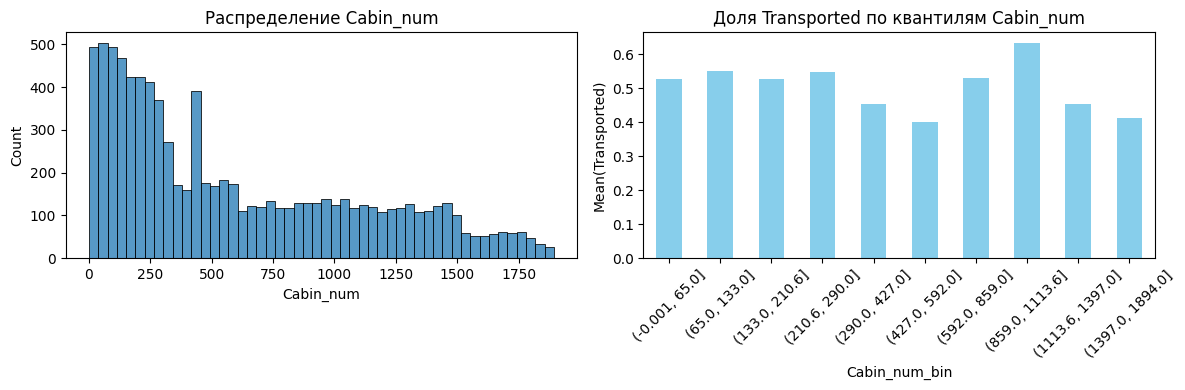

Корреляция Cabin_num с Transported (число -> bool):
-0.04450194075873693

Доля Transported по чётности Cabin_num:
Cabin_num_parity
0    0.495367
1    0.511374
Name: Transported, dtype: float64


In [75]:

# 1. Распределение Cabin_num
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train_df_ext['Cabin_num'], bins=50, kde=False)
plt.title('Распределение Cabin_num')
plt.xlabel('Cabin_num')

# 2. Средний Transported по бинам Cabin_num
train_df_ext['Cabin_num_bin'] = pd.qcut(train_df_ext['Cabin_num'], q=10, duplicates='drop')
bin_means = train_df_ext.groupby('Cabin_num_bin')['Transported'].mean()

plt.subplot(1, 2, 2)
bin_means.plot(kind='bar', color='skyblue')
plt.title('Доля Transported по квантилям Cabin_num')
plt.ylabel('Mean(Transported)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 3. Корреляция
print("Корреляция Cabin_num с Transported (число -> bool):")
print(train_df_ext[['Cabin_num', 'Transported']].corr().iloc[0, 1])

# 4. Проверим чёт/нечёт
train_df_ext['Cabin_num_parity'] = (train_df_ext['Cabin_num'] % 2).astype(int)
parity_means = train_df_ext.groupby('Cabin_num_parity')['Transported'].mean()
print("\nДоля Transported по чётности Cabin_num:")
print(parity_means)

In [79]:
# Копируем, чтобы не портить исходные данные
train_filled = train_df.copy()
test_filled = test_df.copy()

def fill_cabin_by_group(df):
    df = df.copy()
    # Создаём Group из PassengerId
    df['Group'] = df['PassengerId'].str.split('_', expand=True)[0]
    
    # Для каждой группы — ищем непустой Cabin
    group_cabins = df.groupby('Group')['Cabin'].apply(
        lambda x: x.dropna().iloc[0] if not x.dropna().empty else None
    ).to_dict()
    
    # Заполняем
    df['Cabin_filled'] = df.apply(
        lambda row: group_cabins.get(row['Group'], row['Cabin']) if pd.isna(row['Cabin']) else row['Cabin'],
        axis=1
    )
    
    # Считаем, сколько заполнили
    filled_count = df['Cabin'].isna().sum() - df['Cabin_filled'].isna().sum()
    print(f"Заполнено Cabin через Group: {filled_count} значений")
    print("Осталось пропусков:", df['Cabin_filled'].isna().sum())
    
    return df

train_filled = fill_cabin_by_group(train_filled)
test_filled = fill_cabin_by_group(test_filled)

Заполнено Cabin через Group: 100 значений
Осталось пропусков: 99
Заполнено Cabin через Group: 0 значений
Осталось пропусков: 0


In [81]:
train_filled

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Group,Cabin_filled
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0001,B/0/P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0002,F/0/S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,0003,A/0/S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,0003,A/0/S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0004,F/1/S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False,9276,A/98/P
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False,9278,G/1499/S
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True,9279,G/1500/S
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False,9280,E/608/S


In [82]:
# Работаем с исходным train_df — чисто для анализа пропусков
train_raw = train_df.copy()
train_raw['Group'] = train_raw['PassengerId'].str.split('_', expand=True)[0]

# Строки с пропуском Cabin
nan_cabin = train_raw[train_raw['Cabin'].isna()].copy()

print("Всего пропусков Cabin в train:", len(nan_cabin))

print("\n1. Распределение по GroupSize (группам, где все без Cabin):")
group_sizes = nan_cabin.groupby('Group').size()
print("Размеры таких групп:")
print(group_sizes.value_counts().sort_index())

print("\n2. CryoSleep среди них:")
print(nan_cabin['CryoSleep'].value_counts(dropna=False))

print("\n3. Age (описательная статистика):")
print(nan_cabin['Age'].describe())

print("\n4. HomePlanet:")
print(nan_cabin['HomePlanet'].value_counts(dropna=False))

print("\n5. Destination:")
print(nan_cabin['Destination'].value_counts(dropna=False))

print("\n6. Пример 5 строк:")
print(nan_cabin[['PassengerId', 'Group', 'CryoSleep', 'Age', 'HomePlanet', 'Destination']].head())

Всего пропусков Cabin в train: 199

1. Распределение по GroupSize (группам, где все без Cabin):
Размеры таких групп:
1    199
Name: count, dtype: int64

2. CryoSleep среди них:
CryoSleep
False    108
True      84
NaN        7
Name: count, dtype: int64

3. Age (описательная статистика):
count    195.000000
mean      29.148718
std       14.562465
min        0.000000
25%       19.000000
50%       28.000000
75%       37.000000
max       75.000000
Name: Age, dtype: float64

4. HomePlanet:
HomePlanet
Earth     95
Europa    61
Mars      37
NaN        6
Name: count, dtype: int64

5. Destination:
Destination
TRAPPIST-1e      127
55 Cancri e       50
PSO J318.5-22     18
NaN                4
Name: count, dtype: int64

6. Пример 5 строк:
    PassengerId Group CryoSleep   Age HomePlanet  Destination
15      0012_01  0012     False  31.0      Earth  TRAPPIST-1e
93      0101_01  0101      True  31.0       Mars  TRAPPIST-1e
103     0110_01  0110     False  32.0     Europa  TRAPPIST-1e
222     0239_01

In [83]:
train_raw = train_df.copy()
train_raw['Group'] = train_raw['PassengerId'].str.split('_', expand=True)[0]

# Группы с ≥2 пассажирами
group_counts = train_raw['Group'].value_counts()
multi_groups = group_counts[group_counts > 1].index
print("Групп с ≥2 пассажирами:", len(multi_groups))

# В этих группах — сколько имеют НЕПУСТОЙ Cabin?
multi_group_data = train_raw[train_raw['Group'].isin(multi_groups)].copy()
filled_in_multi = multi_group_data['Cabin'].notna().sum()
total_in_multi = len(multi_group_data)

print("Всего пассажиров в группах ≥2:", total_in_multi)
print("Из них с известным Cabin:", filled_in_multi)
print("→ Максимум можно заполнить:", total_in_multi - filled_in_multi)

# А сколько из них сейчас NaN?
nan_in_multi = multi_group_data['Cabin'].isna().sum()
print("Сейчас NaN в multi-группах:", nan_in_multi)

Групп с ≥2 пассажирами: 1412
Всего пассажиров в группах ≥2: 3888
Из них с известным Cabin: 3788
→ Максимум можно заполнить: 100
Сейчас NaN в multi-группах: 100


In [84]:
# Начинаем с исходного train_df и test_df
train_filled = train_df.copy()
test_filled = test_df.copy()

# Добавляем Group
train_filled['Group'] = train_filled['PassengerId'].str.split('_', expand=True)[0]
test_filled['Group'] = test_filled['PassengerId'].str.split('_', expand=True)[0]

# === 1. Заполнение через Group (для multi-групп) ===
group_cabin_map = train_filled.groupby('Group')['Cabin'].apply(
    lambda x: x.dropna().iloc[0] if not x.dropna().empty else None
).to_dict()

train_filled['Cabin_v1'] = train_filled['Cabin'].combine_first(
    train_filled['Group'].map(group_cabin_map)
)
test_filled['Cabin_v1'] = test_filled['Cabin'].combine_first(
    test_filled['Group'].map(group_cabin_map)
)

print("После заполнения через Group:")
print("train NaN:", train_filled['Cabin_v1'].isna().sum())
print("test NaN:", test_filled['Cabin_v1'].isna().sum())

# === 2. Для оставшихся NaN (только одиночки) ===
def fill_remaining_cabin(row):
    if pd.notna(row['Cabin_v1']):
        return row['Cabin_v1']
    # Остался NaN → одиночка
    if row['CryoSleep'] == True:
        return 'X/9999/X'
    else:
        # Мода по HomePlanet + Destination (предварительно посчитаем)
        key = (row['HomePlanet'], row['Destination'])
        return home_dest_mode.get(key, 'X/0/X')  # fallback

# Считаем моду Cabin по (HomePlanet, Destination) для CryoSleep=False
train_known = train_filled[train_filled['Cabin'].notna() & (train_filled['CryoSleep'] != True)]
home_dest_mode = train_known.groupby(['HomePlanet', 'Destination'])['Cabin'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else 'X/0/X'
).to_dict()

# Применяем
train_filled['Cabin_filled'] = train_filled.apply(fill_remaining_cabin, axis=1)
test_filled['Cabin_filled'] = test_filled.apply(fill_remaining_cabin, axis=1)

print("\nПосле полного заполнения:")
print("train NaN:", train_filled['Cabin_filled'].isna().sum())
print("test NaN:", test_filled['Cabin_filled'].isna().sum())

После заполнения через Group:
train NaN: 99
test NaN: 0

После полного заполнения:
train NaN: 0
test NaN: 0


In [85]:
# 1. Извлечение частей Cabin
def extract_cabin(df):
    df = df.copy()
    split = df['Cabin_filled'].str.split('/', expand=True)
    df['Cabin_deck'] = split[0]
    df['Cabin_num'] = pd.to_numeric(split[1], errors='coerce')
    df['Cabin_side'] = split[2]
    return df

train_filled = extract_cabin(train_filled)
test_filled = extract_cabin(test_filled)

# 2. GroupSize (пересчитаем, чтобы быть точными)
group_counts = train_filled['Group'].value_counts()
train_filled['GroupSize'] = train_filled['Group'].map(group_counts)
test_filled = test_filled.copy()  # test — без GroupSize из train, но ок

train_filled['IsAlone'] = (train_filled['GroupSize'] == 1)

# 3. FamilySize через LastName
train_filled['LastName'] = train_filled['Name'].str.split().str[-1]
family_counts = train_filled['LastName'].value_counts()
train_filled['FamilySize'] = train_filled['LastName'].map(family_counts).fillna(1)

# 4. Spending features (как раньше)
def add_spending(df):
    df = df.copy()
    df['TotalSpent'] = df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)
    df['LuxurySpent'] = df[['Spa', 'VRDeck', 'RoomService']].sum(axis=1)
    df['EssentialSpent'] = df[['FoodCourt', 'ShoppingMall']].sum(axis=1)
    df['HasSpent'] = (df['TotalSpent'] > 0).astype(int)
    df['IsCryoSleepTrue'] = df['CryoSleep'].fillna(False).astype(int)
    df['LogTotalSpent'] = np.log1p(df['TotalSpent'])
    return df

train_filled = add_spending(train_filled)
test_filled = add_spending(test_filled)

# 5. Финальный список признаков (22 + Cabin_num_high)
final_cols = [
    'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
    'GroupSize', 'FamilySize', 'TotalSpent', 'LuxurySpent', 'EssentialSpent',
    'LogTotalSpent', 'Cabin_num', 'IsAlone', 'HasSpent', 'IsCryoSleepTrue', 'VIP',
    'HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side'
]

# 6. Подготовка X, y
X = train_filled[final_cols]
y = train_filled['Transported'].astype(int)

# 7. Кодирование категориальных (LabelEncoder)
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
X_enc = X.copy()
test_enc = test_filled[final_cols].copy()

for col in ['HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side']:
    le = LabelEncoder()
    le.fit(pd.concat([X[col].astype(str), test_enc[col].astype(str)]))
    X_enc[col] = le.transform(X[col].astype(str))
    test_enc[col] = le.transform(test_enc[col].astype(str))
    label_encoders[col] = le

# 8. LGBM CV
from lightgbm import LGBMClassifier, early_stopping
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, f1_score
import numpy as np

cat_idx = [X_enc.columns.get_loc(c) for c in ['HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side']]

oof = np.zeros(len(X_enc))
test_pred = np.zeros(len(test_enc))

skf = StratifiedKFold(5, shuffle=True, random_state=42)
for fold, (tr, val) in enumerate(skf.split(X_enc, y)):
    X_tr, X_val = X_enc.iloc[tr], X_enc.iloc[val]
    y_tr, y_val = y.iloc[tr], y.iloc[val]
    
    model = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.02,
        max_depth=6,
        colsample_bytree=0.8,
        subsample=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        verbose=-1
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='average_precision',
        callbacks=[early_stopping(50, verbose=False)],
        categorical_feature=cat_idx
    )
    
    oof[val] = model.predict_proba(X_val)[:, 1]
    test_pred += model.predict_proba(test_enc)[:, 1] / 5

pr_auc = average_precision_score(y, oof)
f1 = f1_score(y, (oof >= 0.35).astype(int))

print(f"\n✅ ФИНАЛЬНАЯ МОДЕЛЬ:")
print(f"OOF PR-AUC: {pr_auc:.4f}")
print(f"OOF F1 @ thr=0.35: {f1:.4f}")

# 9. Submission
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': (test_pred >= 0.35).astype(bool)
})
submission.to_csv('submission_final.csv', index=False)
print("\n✅ submission_final.csv сохранён!")

/tmp/ipykernel_24553/2585415185.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['IsCryoSleepTrue'] = df['CryoSleep'].fillna(False).astype(int)


KeyError: "['GroupSize', 'FamilySize', 'IsAlone'] not in index"